In [1]:
from data_model.DataCleaner import *
from dl_client import DatalakeClient
from tests_utils.manage_excel_support_file import *
from MergerTools import *
import pandas as pd
import os
import json

client = DatalakeClient()
mergeTools = MergerTools()

In [2]:
file_codes = ['UCSFFSX', 'UCSFFSX51', 'UCSFFSX6', 'UCSFFSX7', 'UCSFFSL', 'UCSDVOL', 'UPENN_ROI_MARS']
search = client.query_files(
    query={'custom.level' : 'cleaned_04', 'custom.source' : 'ADNI', 'custom.file_code': file_codes})

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True)

print(len(zip_files))

7


In [3]:
dfs = {}
df_names = {}
df_code = []
for idx, (file_name, df_raw) in enumerate(zip_files.items()):
    df_copy = df_raw.copy(deep=True)
    df_copy['EXAMDATE'] = pd.to_datetime(df_copy['EXAMDATE'])
    df_copy = df_copy.sort_values(by=['RID', 'EXAMDATE']).reset_index(drop=True)
    # aggiornamento liste e dizionari
    dfs[f"df_{idx}"] = df_copy  
    df_names[f"df_{idx}"] = file_name 
    df_code.append(f"df_{idx}")
    # definizione variabile df
    globals()[f"df_{idx}"] = df_copy
    print(idx, '--->', file_name)


0 ---> UCSFFSX_11_02_15_11Aug2025_04.csv
1 ---> UCSFFSX7_11Aug2025_04.csv
2 ---> UCSFFSX6_11Aug2025_04.csv
3 ---> UCSFFSX51_11_08_19_11Aug2025_04.csv
4 ---> UCSFFSL_02_01_16_11Aug2025_04.csv
5 ---> UPENNROI_MARS_06_01_16_09Oct2025_04.csv
6 ---> UCSDVOL_28Oct2025_04.csv


In [4]:
import json
# Apri e carica il file diff_tracking.json
if os.path.exists('diff_mean_tracking.json'):
    with open('diff_mean_tracking.json', 'r') as f:
        diff_mean = json.load(f)
else:
    print("############################################\nJSON non creato: il file diff_mean_tracking.json non esiste")

if os.path.exists('diff_in_col_tracking.json'):
    with open('diff_in_col_tracking.json', 'r') as f:
        in_col = json.load(f)
else:
    print("############################################\nJSON non creato: il file diff_in_col_tracking.json non esiste")


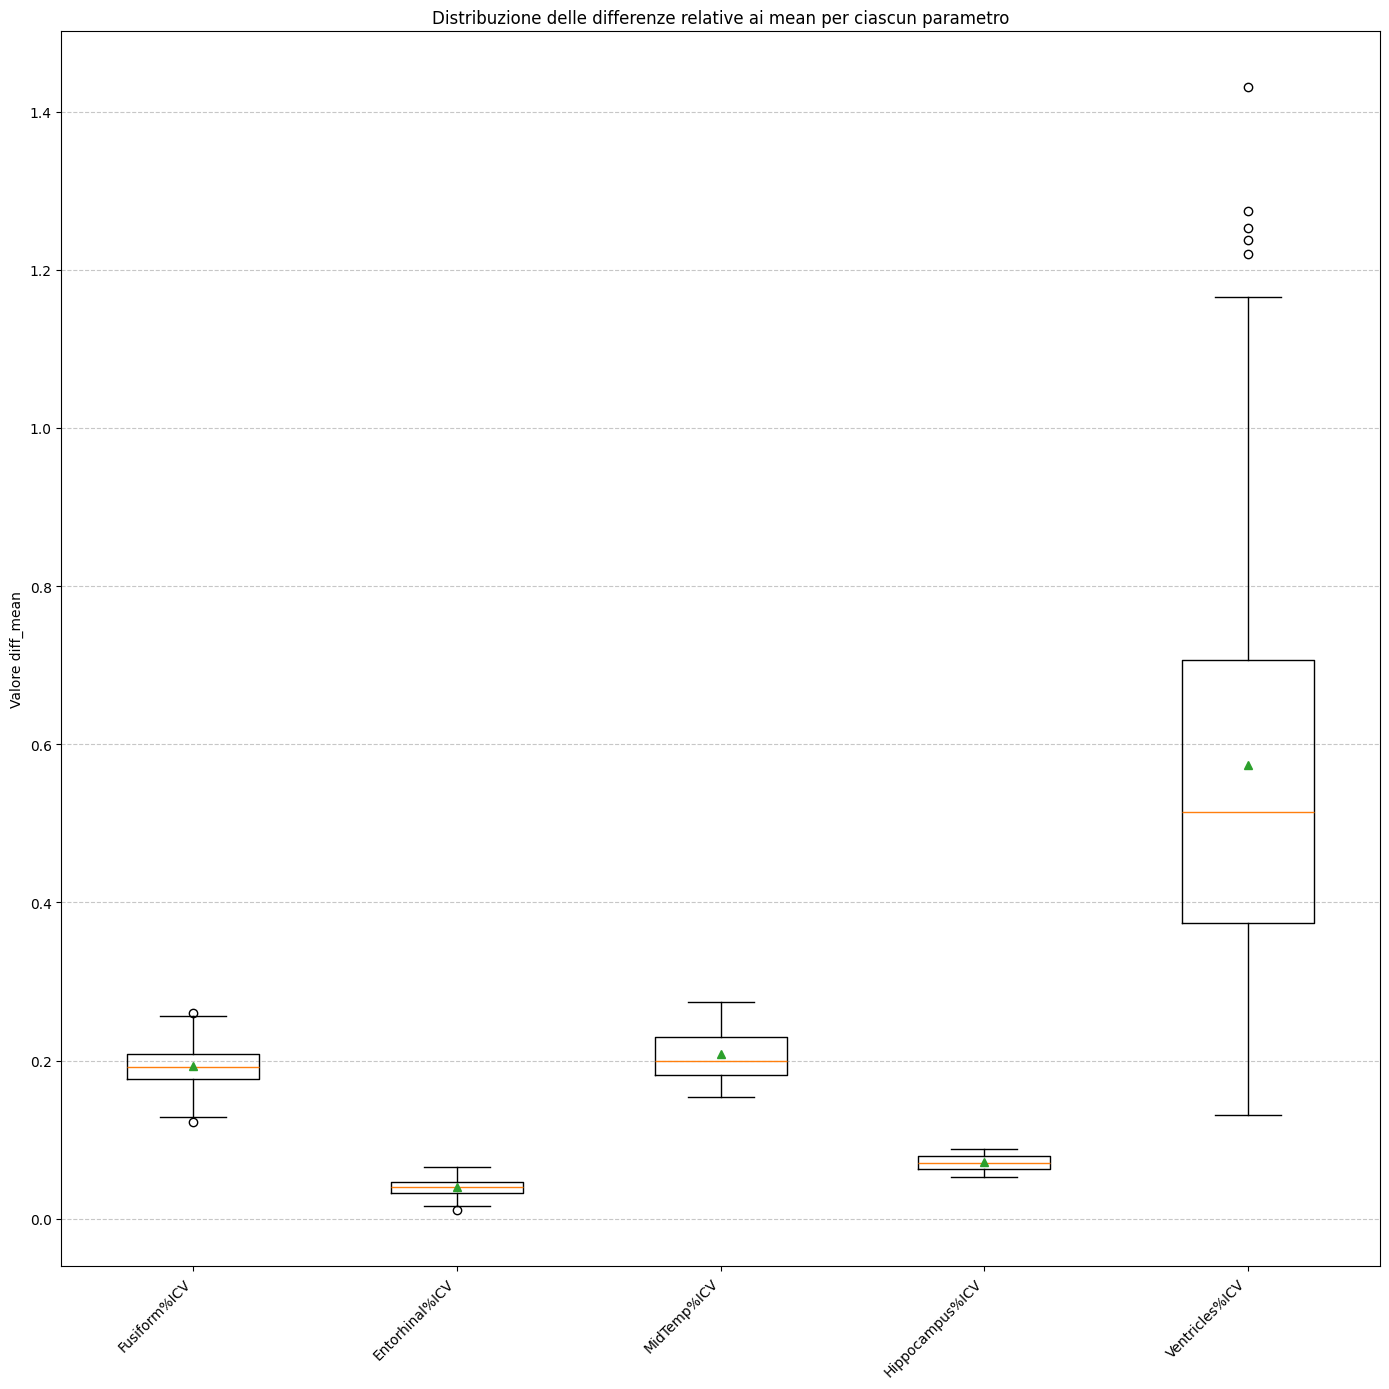

In [5]:
import matplotlib.pyplot as plt

# Raccogli i valori da visualizzare nel boxplot
boxplot_data = [np.asarray([x[1] for x in diff_mean[key]]) for key in diff_mean.keys()]
labels = list(diff_mean.keys())

plt.figure(figsize=(14,14))  # aumenta l'altezza da 6 a 10
plt.boxplot(boxplot_data, labels=labels, showmeans=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Valore diff_mean')
plt.title('Distribuzione delle differenze relative ai mean per ciascun parametro')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)  # aggiungi griglia orizzontale per chiarezza
plt.show()



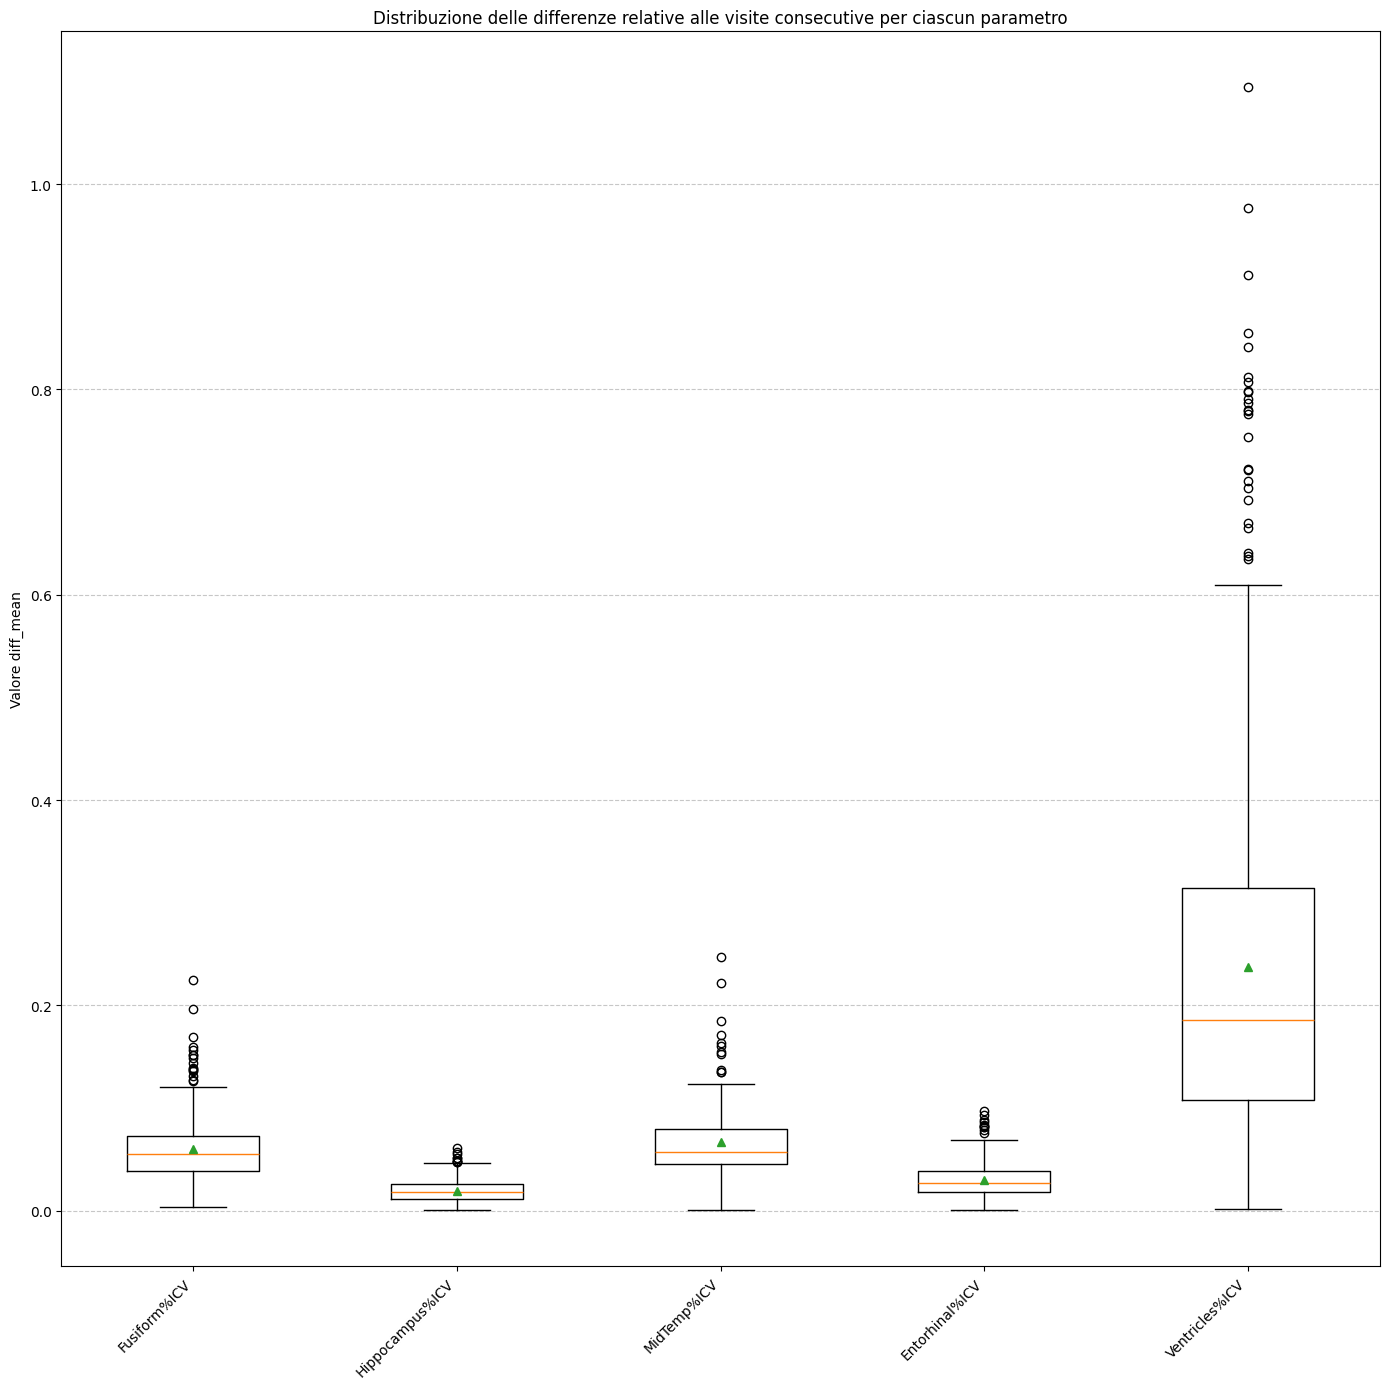

In [6]:
# Raccogli i valori da visualizzare nel boxplot
boxplot_data = [np.asarray([x[1] for x in in_col[key]]) for key in in_col.keys()]
labels = list(in_col.keys())

plt.figure(figsize=(14,14))  # aumenta l'altezza da 6 a 10
plt.boxplot(boxplot_data, labels=labels, showmeans=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Valore diff_mean')
plt.title('Distribuzione delle differenze relative alle visite consecutive per ciascun parametro')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)  # aggiungi griglia orizzontale per chiarezza
plt.show()

In [7]:
diff_json = pd.DataFrame(index=['mean_mean', 'mean_std', 'mean_min', 'mean_max', 'in_col_mean', 'in_col_std', 'in_col_min', 'in_col_max'], columns=list(diff_mean.keys()))
for key in diff_mean.keys():
    diff_mean_val = np.asarray([x[1] for x in diff_mean[key]])
    diff_json.loc['mean_mean', key] = np.mean(diff_mean_val)
    diff_json.loc['mean_std', key] = np.std(diff_mean_val)
    diff_json.loc['mean_min', key] = np.min(diff_mean_val)
    diff_json.loc['mean_max', key] = np.max(diff_mean_val)

    diff_in_col_val = np.asarray([x[1] for x in in_col[key]])
    diff_json.loc['in_col_mean', key] = np.mean(diff_in_col_val)
    diff_json.loc['in_col_std', key] = np.std(diff_in_col_val)
    diff_json.loc['in_col_min', key] = np.min(diff_in_col_val)
    diff_json.loc['in_col_max', key] = np.max(diff_in_col_val)

#diff_json.to_csv('diff_json.csv')


In [8]:

if os.path.exists('volume_values_settings.json'):
    with open('volume_values_settings.json', 'r') as f:
        volumes_json = json.load(f)
        volume_cols = list(volumes_json.keys())
else:
    print("############################################\nJSON non creato: il file volume_values_settings.json non esiste")

In [13]:
volume_cols = [x for x in volume_cols if '%ICV' in x and x!='ICV%ICV']
diff_volumes = {x:[] for x in volume_cols}

for df in dfs.values():
    rid_list = df['RID'].unique().tolist()
    vol_cols = [x for x in df.columns if x in volume_cols]
    for col in vol_cols:
        for rid in rid_list:
                df_sub = df[df['RID'] == rid][col].copy(deep=True)
                diff_volumes[col].extend((df_sub.shift(0) - df_sub.shift(-1)).abs().iloc[:-1].tolist())

In [14]:
diff_volumes_df = pd.DataFrame(index=volume_cols, columns=['diff_mean', 'diff_std', 'diff_min', 'diff_max', 'diff_99'])
for col in volume_cols:
    diff_volumes_df.loc[col, 'diff_mean'] = np.nanmean(diff_volumes[col])
    diff_volumes_df.loc[col, 'diff_std'] = np.nanstd(diff_volumes[col])
    diff_volumes_df.loc[col, 'diff_min'] = np.nanmin(diff_volumes[col])
    diff_volumes_df.loc[col, 'diff_max'] = np.nanmax(diff_volumes[col])
    diff_volumes_df.loc[col, 'diff_99'] = np.nanpercentile(diff_volumes[col], 99)
#diff_volumes_df.to_csv('diff_volumes_df.csv')

In [15]:
diff_volumes_df

,diff_mean,diff_std,diff_min,diff_max,diff_99
Brain%ICV,0.487854,0.400692,0.0,3.163035,1.776977
Ventricles%ICV,0.143127,0.182815,0.000024,5.006342,0.796495
Hippocampus%ICV,0.012691,0.014656,0.0,0.389395,0.063565
Entorhinal%ICV,0.017574,0.0169,0.000007,0.204803,0.076908
Fusiform%ICV,0.038999,0.039795,0.000001,0.885628,0.169876
MidTemp%ICV,0.041383,0.0419,0.000001,0.840993,0.190972


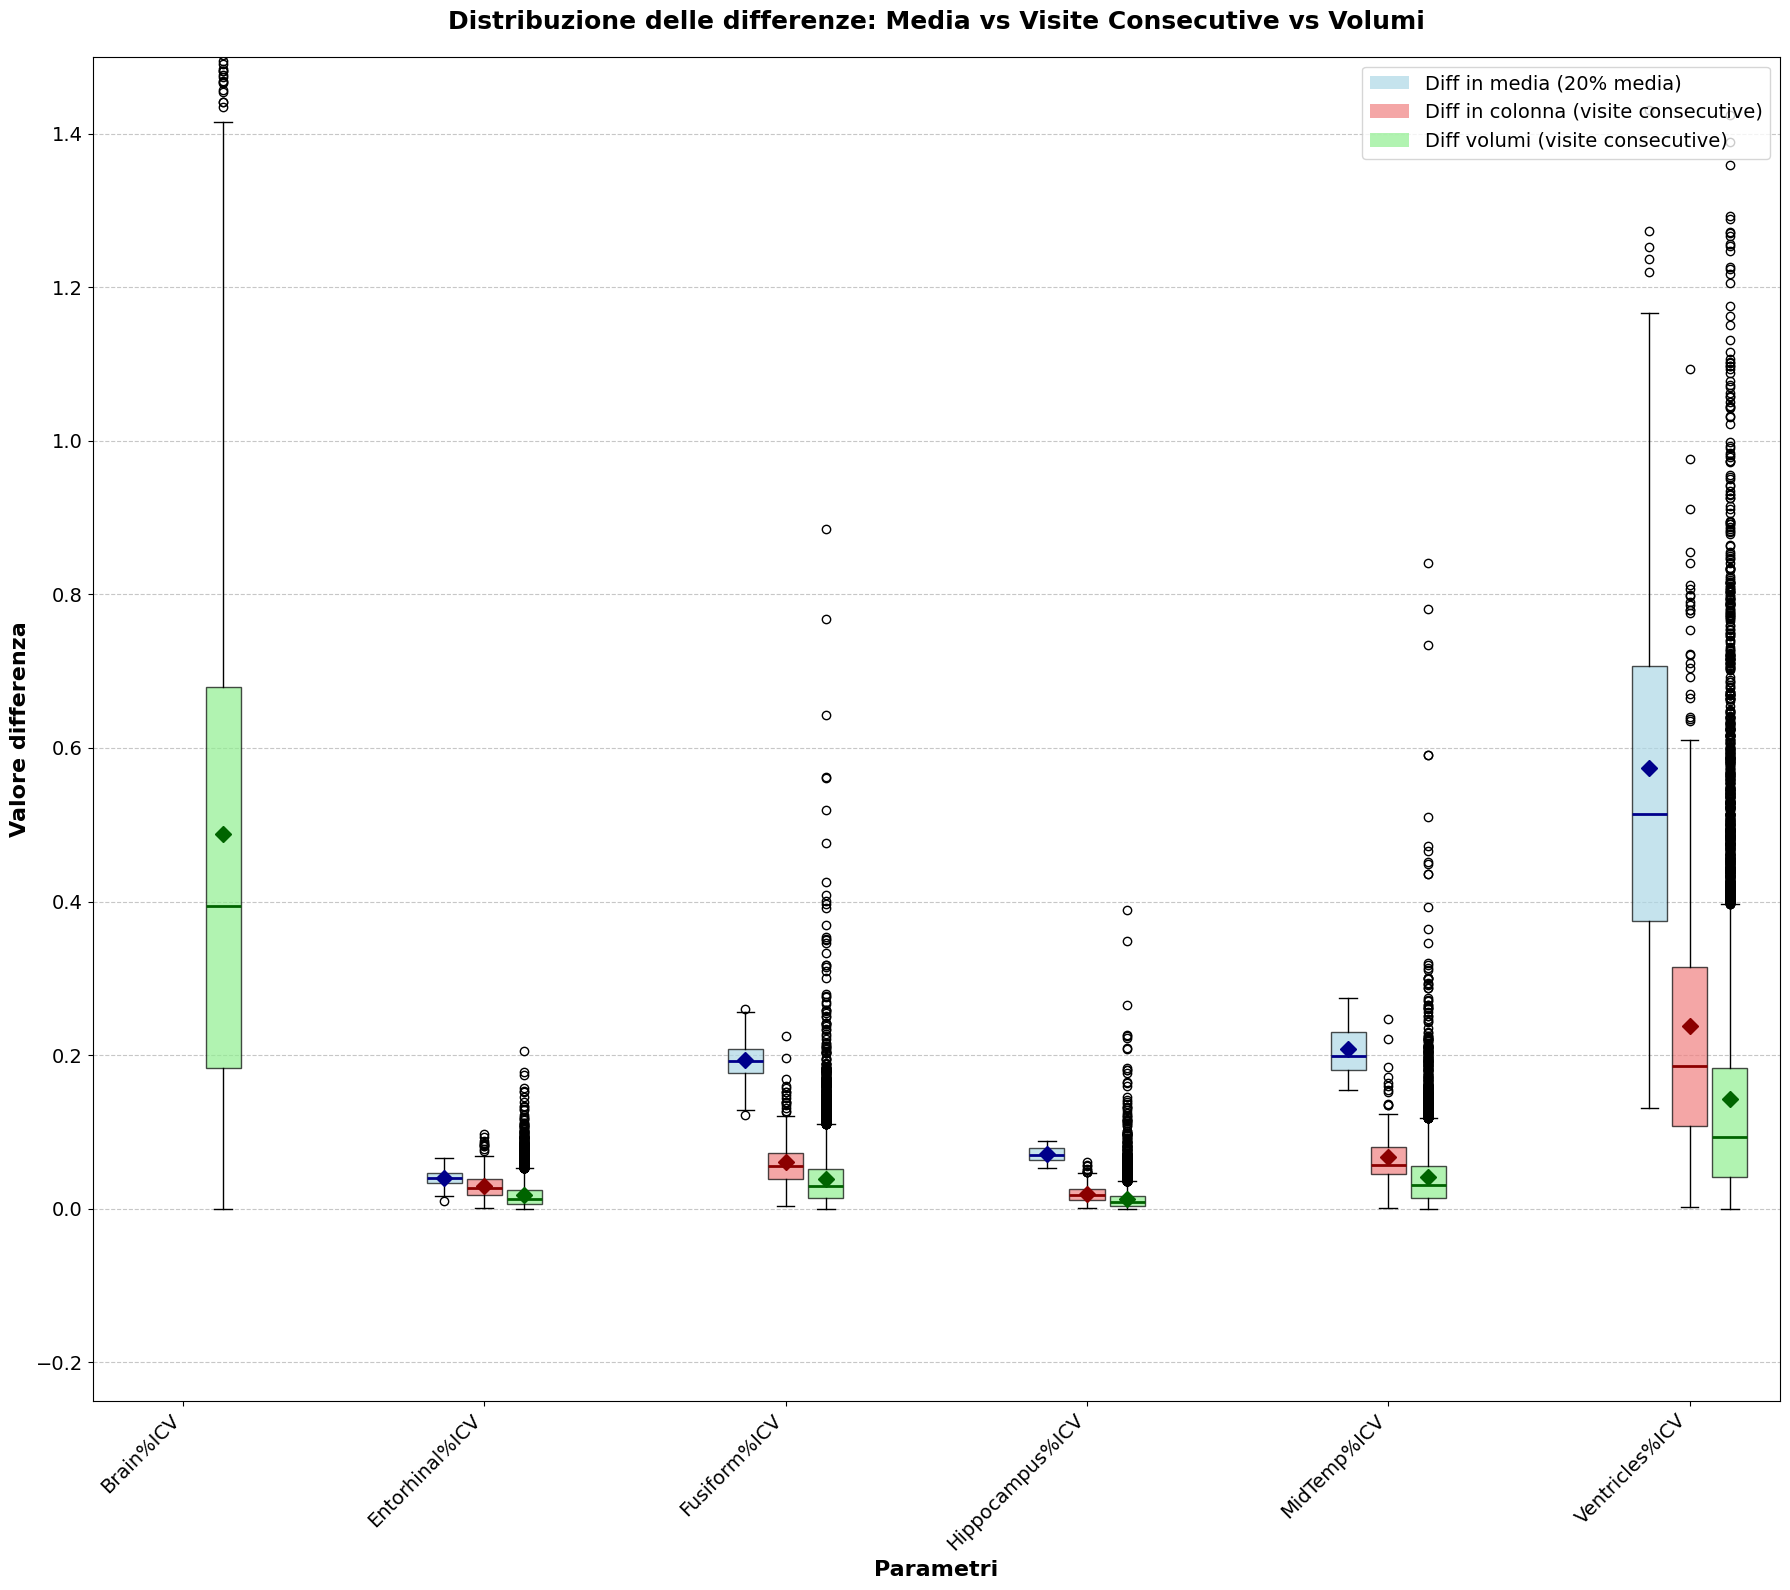

In [16]:
# Prepara i dati per il boxplot combinato
# Assicuriamoci che tutti i dizionari abbiano le stesse chiavi
all_keys = sorted(set(list(diff_mean.keys()) + list(in_col.keys()) + list(diff_volumes.keys())))

# Crea liste separate per diff_mean, diff_in_col e diff_volumes
diff_mean_data = []
diff_in_col_data = []
diff_volumes_data = []
labels = []

for key in all_keys:
    if key in diff_mean:
        diff_mean_data.append(np.asarray([x[1] for x in diff_mean[key]]))
    else:
        diff_mean_data.append(np.asarray([]))
    
    if key in in_col:
        diff_in_col_data.append(np.asarray([x[1] for x in in_col[key]]))
    else:
        diff_in_col_data.append(np.asarray([]))
    
    if key in diff_volumes:
        # diff_volumes contiene direttamente una lista di valori (non liste annidate)
        diff_volumes_data.append(np.asarray([x for x in diff_volumes[key] if not pd.isna(x)]))
    else:
        diff_volumes_data.append(np.asarray([]))
    
    labels.append(key)

# Crea il grafico
fig, ax = plt.subplots(figsize=(18, 16))

# Posizioni per i boxplot (affiancati per ogni parametro)
# Ora abbiamo 3 boxplot per ogni parametro
positions_mean = np.arange(len(all_keys)) * 3 - 0.4
positions_in_col = np.arange(len(all_keys)) * 3
positions_volumes = np.arange(len(all_keys)) * 3 + 0.4

# Crea i boxplot
bp1 = ax.boxplot(diff_mean_data, positions=positions_mean, widths=0.35, 
                 patch_artist=True, showmeans=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='darkblue', linewidth=2),
                 meanprops=dict(marker='D', markerfacecolor='darkblue', markeredgecolor='darkblue', markersize=8))

bp2 = ax.boxplot(diff_in_col_data, positions=positions_in_col, widths=0.35,
                 patch_artist=True, showmeans=True,
                 boxprops=dict(facecolor='lightcoral', alpha=0.7),
                 medianprops=dict(color='darkred', linewidth=2),
                 meanprops=dict(marker='D', markerfacecolor='darkred', markeredgecolor='darkred', markersize=8))

bp3 = ax.boxplot(diff_volumes_data, positions=positions_volumes, widths=0.35,
                 patch_artist=True, showmeans=True,
                 boxprops=dict(facecolor='lightgreen', alpha=0.7),
                 medianprops=dict(color='darkgreen', linewidth=2),
                 meanprops=dict(marker='D', markerfacecolor='darkgreen', markeredgecolor='darkgreen', markersize=8))

# Imposta le etichette sull'asse x
ax.set_xticks(np.arange(len(all_keys)) * 3)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=14)

# Aggiungi legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', alpha=0.7, label='Diff in media (20% media)'),
    Patch(facecolor='lightcoral', alpha=0.7, label='Diff in colonna (visite consecutive)'),
    Patch(facecolor='lightgreen', alpha=0.7, label='Diff volumi (visite consecutive)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14)

# Aggiungi etichette e titolo
ax.set_ylabel('Valore differenza', fontsize=16, fontweight='bold')
ax.set_xlabel('Parametri', fontsize=16, fontweight='bold')
ax.set_title('Distribuzione delle differenze: Media vs Visite Consecutive vs Volumi', fontsize=18, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Aumenta anche la dimensione dei tick labels sull'asse y
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(top=1.5)  # Set y-axis limit

plt.tight_layout()
plt.show()
